In [ ]:
import pandas as pd
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# Check dataset summary and missing values
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha             

In [ ]:
# Missing values-a median vechu fill panrom
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

# Verification: Ellam 0 aagiducha-nu check panna
print("Remaining missing values:")
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

Remaining missing values:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


/tmp/ipykernel_773/3081305309.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0, 0], palette='Greens_d')
/tmp/ipykernel_773/3081305309.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', estimator=sum, ax=axes[0, 1], palette='Blues_d')
/tmp/ipykernel_773/3081305309.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1, 1], palette='Oranges')


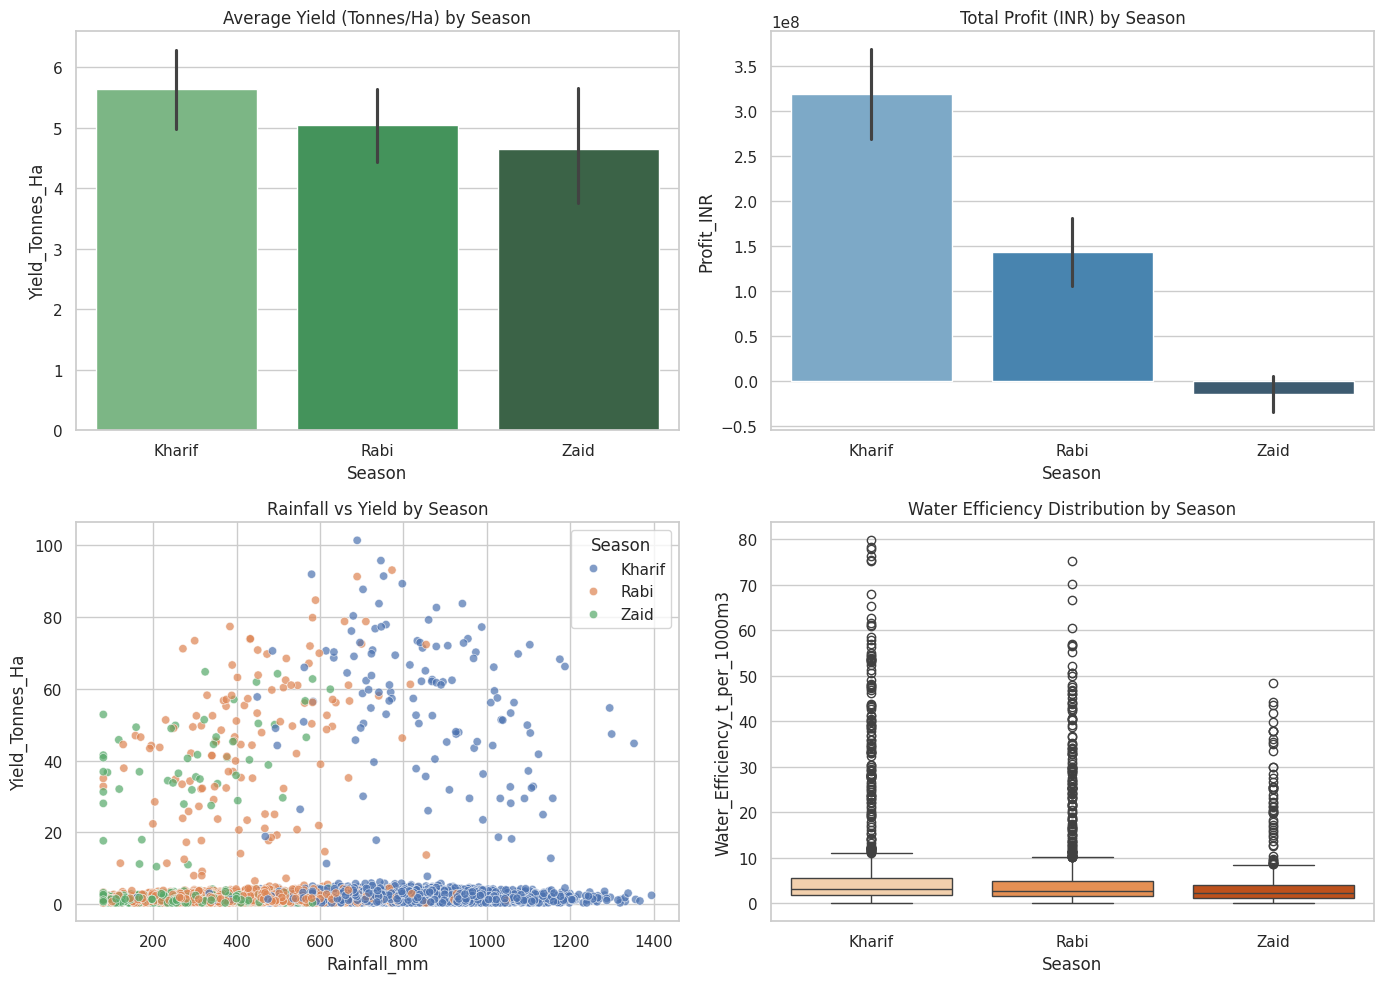

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Average Yield by Season
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0, 0], palette='Greens_d')
axes[0, 0].set_title('Average Yield (Tonnes/Ha) by Season')

# Chart 2: Total Profit by Season
sns.barplot(data=df, x='Season', y='Profit_INR', estimator=sum, ax=axes[0, 1], palette='Blues_d')
axes[0, 1].set_title('Total Profit (INR) by Season')

# Chart 3: Rainfall vs Crop Yield
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title('Rainfall vs Yield by Season')

# Chart 4: Water Usage Efficiency by Season
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[1, 1], palette='Oranges')
axes[1, 1].set_title('Water Efficiency Distribution by Season')

plt.tight_layout()
plt.show()

Seasonal Agricultural Performance Analysis - Key Insights
  Highest Performing Season (Kharif):
   The Kharif season shows high performance. It records an Average Yield of ~5.63 Tonnes/Ha and the highest Total Profit of ₹31.8 Crores. High rainfall support reduces overall cultivation costs.  

  Moderate Season (Rabi):
   The Rabi season shows moderate performance. It records an Average Yield of ~5.04 Tonnes/Ha and a Total Profit of ₹14.2 Crores.  
   
  Low/Negative Profit Season (Zaid):
   The Zaid season records the lowest yield (~4.64 Tonnes/Ha) and an overall negative profit (-₹1.47 Crores). High temperatures and low rainfall significantly increase irrigation costs.
   
  Water & Rainfall Relationship:
   Water usage efficiency is highest during high-rainfall seasons, whereas dry seasons like Zaid show a higher reliance on heavy irrigation.
   
 Final Recommendations for Agricultural Planning

  1.  Focus on Kharif & Rabi: Allocate the majority of resource investments toward Kharif and Rabi crop production to maximize returns.  

  2. Optimize Zaid Crop Selection: Identify and cultivate drought-resistant or low-water-consuming crops specifically for the Zaid season.

  3. Adopt Drip Irrigation for Zaid: Transition from flood irrigation to drip irrigation during the Zaid season to minimize water wastage and control operational costs.  